In [8]:
import os
import torch
from wordcloud import WordCloud
import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [9]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/DS310/Project/Dataset/datasets/Multi-Label dataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


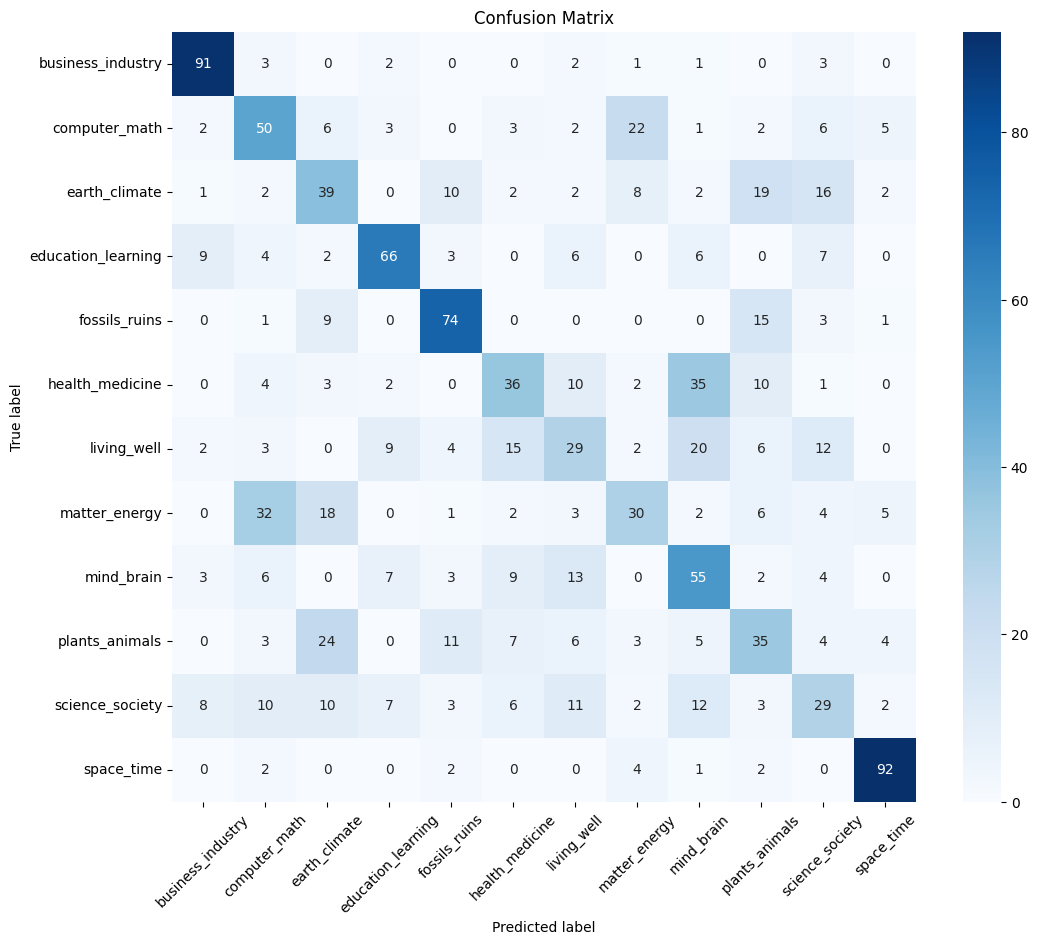

In [7]:
all_dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        label = file.replace("_papers.csv", "")
        df = pd.read_csv(os.path.join(folder_path, file))

        df["category"] = label

        all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)
print("Tổng số dòng:", len(merged_df))
merged_df.head()

Tổng số dòng: 12313


,title,link,date_posted,headline,source,related_topics,abstract,full_story,category
0,'Old Smokers' and 'Squalling Newborns' Among H...,https://www.sciencedaily.com/releases/2024/01/...,"January 27, 2024",'Old smokers' and 'squalling newborns' among h...,Royal Astronomical Society,Space & Time,'Hidden' stars including a new type of elderly...,'Hidden' stars including a new type of elderly...,space_time.csv
1,Stars Travel More Slowly at Milky Way's Edge,https://www.sciencedaily.com/releases/2024/01/...,"January 26, 2024",Stars travel more slowly at Milky Way's edge,Massachusetts Institute of Technology,Space & Time,Physicists discovered stars near the edge of t...,By clocking the speed of stars throughout the ...,space_time.csv
2,Astronomers Unravel Mysteries of Planet Format...,https://www.sciencedaily.com/releases/2024/01/...,"January 29, 2024",Astronomers unravel mysteries of planet format...,University of California - Irvine,Space & Time,"TOI-1136, a dwarf star located more than 270 l...",A recently discovered solar system with six co...,space_time.csv
3,Confirmation of Ancient Lake on Mars Builds Ex...,https://www.sciencedaily.com/releases/2024/01/...,"January 26, 2024",Confirmation of ancient lake on Mars builds ex...,University of California - Los Angeles,Space & Time,Ground-penetrating radar on board NASA's Mars ...,"If life ever existed on Mars, the Perseverance...",space_time.csv
4,Cosmic Building Blocks of Life Discovered Thro...,https://www.sciencedaily.com/releases/2024/01/...,"January 29, 2024",Cosmic building blocks of life discovered thro...,University of Münster,Plants & Animals|Space & Time|Fossils & Ruins,Meteorites are fragments of asteroids which fi...,A research team analyses extraterrestrial amin...,space_time.csv


## Kiểm tra dataset

In [10]:
topic_counts = (
    merged_df
    .explode('related_topics')
    ['related_topics']
    .value_counts()
)

In [11]:
topic_counts.head(20)

,count
related_topics,
Health & Medicine|Mind & Brain,1247
Health & Medicine,772
Space & Time,718
Mind & Brain,718
Matter & Energy|Computers & Math,697
Mind & Brain|Science & Society,654
Plants & Animals|Earth & Climate,564
Plants & Animals|Fossils & Ruins,463
Health & Medicine|Plants & Animals,426


In [12]:
merged_df['related_topics_split'] = merged_df['related_topics'].str.split('|')

topic_counts = (
    merged_df
    .explode('related_topics_split')
    ['related_topics_split']
    .value_counts()
)

topic_counts.head(10)

,count
related_topics_split,
Health & Medicine,4202
Mind & Brain,3989
Plants & Animals,3013
Science & Society,2881
Earth & Climate,2829
Matter & Energy,2563
Computers & Math,2182
Fossils & Ruins,1373
Space & Time,1253


In [13]:
merged_df

,title,link,date_posted,headline,source,related_topics,abstract,full_story,category,related_topics_split
0,'Old Smokers' and 'Squalling Newborns' Among H...,https://www.sciencedaily.com/releases/2024/01/...,"January 27, 2024",'Old smokers' and 'squalling newborns' among h...,Royal Astronomical Society,Space & Time,'Hidden' stars including a new type of elderly...,'Hidden' stars including a new type of elderly...,space_time.csv,[Space & Time]
1,Stars Travel More Slowly at Milky Way's Edge,https://www.sciencedaily.com/releases/2024/01/...,"January 26, 2024",Stars travel more slowly at Milky Way's edge,Massachusetts Institute of Technology,Space & Time,Physicists discovered stars near the edge of t...,By clocking the speed of stars throughout the ...,space_time.csv,[Space & Time]
2,Astronomers Unravel Mysteries of Planet Format...,https://www.sciencedaily.com/releases/2024/01/...,"January 29, 2024",Astronomers unravel mysteries of planet format...,University of California - Irvine,Space & Time,"TOI-1136, a dwarf star located more than 270 l...",A recently discovered solar system with six co...,space_time.csv,[Space & Time]
3,Confirmation of Ancient Lake on Mars Builds Ex...,https://www.sciencedaily.com/releases/2024/01/...,"January 26, 2024",Confirmation of ancient lake on Mars builds ex...,University of California - Los Angeles,Space & Time,Ground-penetrating radar on board NASA's Mars ...,"If life ever existed on Mars, the Perseverance...",space_time.csv,[Space & Time]
4,Cosmic Building Blocks of Life Discovered Thro...,https://www.sciencedaily.com/releases/2024/01/...,"January 29, 2024",Cosmic building blocks of life discovered thro...,University of Münster,Plants & Animals|Space & Time|Fossils & Ruins,Meteorites are fragments of asteroids which fi...,A research team analyses extraterrestrial amin...,space_time.csv,"[Plants & Animals, Space & Time, Fossils & Ruins]"
...,...,...,...,...,...,...,...,...,...,...
12308,The Secret Water Vault Under Our Feet,https://www.sciencedaily.com/releases/2025/12/...,"December 26, 2025",How Earth endured a planet-wide inferno: The s...,Chinese Academy of Sciences Headquarters,Space & Time|Earth & Climate,"When Earth was a molten inferno, water may hav...",Earth’s oceans may have survived the planet’s ...,fossils_ruins.csv,"[Space & Time, Earth & Climate]"
12309,A Vast Cosmic Structure Is Spinning,https://www.sciencedaily.com/releases/2025/12/...,"December 25, 2025",Astronomers discover one of the Universe’s lar...,University of Oxford,Space & Time,Scientists have discovered a giant cosmic fila...,A figure illustrating the rotation of neutral ...,fossils_ruins.csv,[Space & Time]
12310,A Strange Star Near a Silent Black Hole,https://www.sciencedaily.com/releases/2025/12/...,"December 26, 2025",A strange star near a black hole is defying ex...,University of Hawaii at Manoa,Space & Time,Astronomers have decoded the hidden past of a ...,AI-generated image of red giant star orbiting ...,fossils_ruins.csv,[Space & Time]
12311,Common Food Ingredient May Affect Kids for Life,https://www.sciencedaily.com/releases/2025/12/...,"December 26, 2025",This common food ingredient may shape a child’...,Institut Pasteur,Health & Medicine,Scientists discovered that common food emulsif...,Molecules passing through the colon epithelium...,fossils_ruins.csv,[Health & Medicine]


In [14]:
pip install transformers datasets torch scikit-learn pandas numpy tqdm

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

In [16]:
labels = [
    "Health & Medicine",
    "Mind & Brain",
    "Plants & Animals",
    "Science & Society",
    "Earth & Climate",
    "Matter & Energy",
    "Computers & Math",
    "Fossils & Ruins",
    "Space & Time"
]

In [17]:
df = merged_df
# cột text: "abstract" hoặc "content"
# cột label: "related_topics"

LABELS = [
    "Health & Medicine",
    "Mind & Brain",
    "Plants & Animals",
    "Science & Society",
    "Earth & Climate",
    "Matter & Energy",
    "Computers & Math",
    "Fossils & Ruins",
    "Space & Time"
]

df["related_topics_list"] = df["related_topics"].apply(
    lambda x: [t.strip() for t in x.split("|")]
)

mlb = MultiLabelBinarizer(classes=LABELS)
y = mlb.fit_transform(df["related_topics_list"])

In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    df["abstract"].values,
    y,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42
)

In [19]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

In [20]:
MODEL_NAME = "roberta-base"  # hoặc bert-base-uncased

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [21]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=256,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [22]:
from torch.utils.data import DataLoader

train_ds = NewsDataset(X_train, y_train)
val_ds   = NewsDataset(X_val, y_val)
test_ds  = NewsDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)
test_loader  = DataLoader(test_ds, batch_size=8)

In [23]:
import torch.nn as nn
from transformers import AutoModel

In [24]:
class MultiLabelClassifier(nn.Module):
    def __init__(self, model_name, n_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(self.encoder.config.hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = outputs.last_hidden_state[:, 0]  # CLS
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

In [30]:
label_counts = y_train.sum(axis=0)
pos_weight = (len(y_train) - label_counts) / label_counts
pos_weight = torch.tensor(pos_weight, dtype=torch.float).to(device)

In [31]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [27]:
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiLabelClassifier(MODEL_NAME, len(LABELS)).to(device)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [33]:
from sklearn.metrics import f1_score

In [34]:
def evaluate(model, loader, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()

            preds = (probs > threshold).astype(int)

            all_preds.append(preds)
            all_labels.append(labels)

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    return {
        "micro_f1": f1_score(y_true, y_pred, average="micro"),
        "macro_f1": f1_score(y_true, y_pred, average="macro")
    }

In [35]:
EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Train loss: {train_loss:.4f}")

100%|██████████| 1078/1078 [06:53<00:00,  2.61it/s]



Epoch 1
Train loss: 0.4568


100%|██████████| 1078/1078 [06:53<00:00,  2.61it/s]



Epoch 2
Train loss: 0.2946


100%|██████████| 1078/1078 [06:52<00:00,  2.61it/s]



Epoch 3
Train loss: 0.2089


100%|██████████| 1078/1078 [06:51<00:00,  2.62it/s]



Epoch 4
Train loss: 0.1496


100%|██████████| 1078/1078 [06:52<00:00,  2.61it/s]


Epoch 5
Train loss: 0.1119


# Tìm Threshold tốt nhất

In [36]:
import numpy as np
import torch

def get_val_outputs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels)

    return np.vstack(all_probs), np.vstack(all_labels)

def find_best_thresholds(y_true, y_prob):
    n_labels = y_true.shape[1]
    thresholds = []

    for i in range(n_labels):
        best_f1 = 0
        best_t = 0.5

        for t in np.arange(0.1, 0.9, 0.05):
            preds = (y_prob[:, i] > t).astype(int)
            f1 = f1_score(y_true[:, i], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    return thresholds

In [37]:
val_probs, val_labels = get_val_outputs(model, val_loader)

thresholds = find_best_thresholds(val_labels, val_probs)

print("Thresholds per label:")
for label, t in zip(LABELS, thresholds):
    print(f"{label:20s}: {t:.2f}")

Thresholds per label:
Health & Medicine   : 0.65
Mind & Brain        : 0.10
Plants & Animals    : 0.85
Science & Society   : 0.40
Earth & Climate     : 0.85
Matter & Energy     : 0.80
Computers & Math    : 0.80
Fossils & Ruins     : 0.80
Space & Time        : 0.45


# Lưu Model

In [38]:
import os
os.makedirs("saved_model", exist_ok=True)

In [39]:
torch.save(model.state_dict(), "saved_model/model.pt")
tokenizer.save_pretrained("saved_model")

('saved_model/tokenizer_config.json',
 'saved_model/special_tokens_map.json',
 'saved_model/vocab.json',
 'saved_model/merges.txt',
 'saved_model/added_tokens.json',
 'saved_model/tokenizer.json')

In [40]:
import json

save_info = {
    "labels": LABELS,
    "thresholds": thresholds
}

with open("saved_model/config.json", "w") as f:
    json.dump(save_info, f, indent=2)

In [41]:
with open("saved_model/config.json") as f:
    cfg = json.load(f)

LABELS = cfg["labels"]
thresholds = cfg["thresholds"]

In [42]:
!zip -r /content/drive/MyDrive/saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/tokenizer.json (deflated 82%)
  adding: saved_model/config.json (deflated 56%)
  adding: saved_model/special_tokens_map.json (deflated 52%)
  adding: saved_model/tokenizer_config.json (deflated 75%)
  adding: saved_model/model.pt (deflated 12%)
  adding: saved_model/vocab.json (deflated 59%)
  adding: saved_model/merges.txt (deflated 53%)


# Load Model


In [43]:
import json

with open("saved_model/config.json") as f:
    cfg = json.load(f)

LABELS = cfg["labels"]
thresholds = cfg["thresholds"]

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("saved_model")

model = MultiLabelClassifier(MODEL_NAME, len(LABELS))
model.load_state_dict(torch.load("saved_model/model.pt", map_location=device))
model.to(device)
model.eval()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultiLabelClassifier(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerN

# Kiểm tra tập test

In [44]:
test_probs, test_labels = get_val_outputs(model, test_loader)

In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss, accuracy_score

In [47]:
labels = [
    "Health & Medicine",
    "Mind & Brain",
    "Plants & Animals",
    "Science & Society",
    "Earth & Climate",
    "Matter & Energy",
    "Computers & Math",
    "Fossils & Ruins",
    "Space & Time"
]

thresholds = np.array([0.80, 0.30, 0.60, 0.85, 0.55, 0.70, 0.80, 0.85, 0.60])

def evaluate_with_thresholds(y_true, y_prob, thresholds):
    """
    y_true:  (N, num_labels)  - ground truth (0/1)
    y_prob:  (N, num_labels)  - sigmoid probabilities
    thresholds: list[num_labels]
    """
    y_pred = np.zeros_like(y_true)

    # Áp dụng threshold riêng từng nhãn
    for i, t in enumerate(thresholds):
        y_pred[:, i] = (y_prob[:, i] > t).astype(int)

    # Metrics tổng quát
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    hamming = hamming_loss(y_true, y_pred)
    subset_acc = accuracy_score(y_true, y_pred)

    # Metrics label-wise
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    label_metrics = pd.DataFrame({
        "Label": labels,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Threshold": thresholds
    })

    # FP / FN per label
    fp = np.sum((y_pred == 1) & (y_true == 0), axis=0)
    fn = np.sum((y_pred == 0) & (y_true == 1), axis=0)
    fp_fn = pd.DataFrame({
        "Label": labels,
        "False Positives": fp,
        "False Negatives": fn,
        "Threshold": thresholds
    })

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
        "label_metrics": label_metrics,
        "fp_fn": fp_fn,
        "y_pred": y_pred
    }

# ----------- Evaluate trên test set -----------
test_metrics = evaluate_with_thresholds(
    y_true=test_labels,
    y_prob=test_probs,
    thresholds=thresholds
)

print("===== TEST RESULTS =====")
print(f"Micro F1       : {test_metrics['micro_f1']:.4f}")
print(f"Macro F1       : {test_metrics['macro_f1']:.4f}")
print(f"Hamming Loss   : {test_metrics['hamming_loss']:.4f}")
print(f"Subset Accuracy: {test_metrics['subset_accuracy']:.4f}\n")

print("===== Label-wise Metrics =====")
print(test_metrics['label_metrics'])

print("\n===== FP / FN per Label =====")
print(test_metrics['fp_fn'])

===== TEST RESULTS =====
Micro F1       : 0.8877
Macro F1       : 0.8856
Hamming Loss   : 0.0494
Subset Accuracy: 0.6681

===== Label-wise Metrics =====
               Label  Precision    Recall  F1-score  Threshold
0  Health & Medicine   0.933022  0.895366  0.913806       0.80
1       Mind & Brain   0.936535  0.900990  0.918419       0.30
2   Plants & Animals   0.834382  0.945368  0.886414       0.60
3  Science & Society   0.840659  0.740920  0.787645       0.85
4    Earth & Climate   0.853556  0.931507  0.890830       0.55
5    Matter & Energy   0.864362  0.866667  0.865513       0.70
6   Computers & Math   0.866667  0.920354  0.892704       0.80
7    Fossils & Ruins   0.857955  0.857955  0.857955       0.85
8       Space & Time   0.947619  0.966019  0.956731       0.60

===== FP / FN per Label =====
               Label  False Positives  False Negatives  Threshold
0  Health & Medicine               43               70       0.80
1       Mind & Brain               37               60

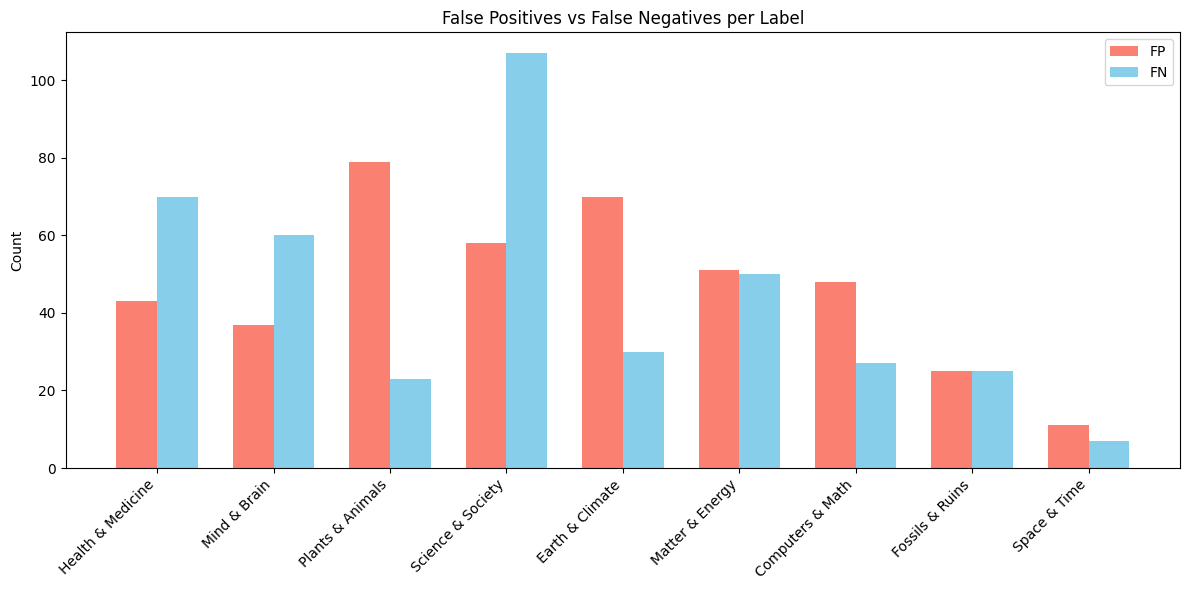

In [50]:
import matplotlib.pyplot as plt
import numpy as np

fp = test_metrics['fp_fn']['False Positives']
fn = test_metrics['fp_fn']['False Negatives']
labels = test_metrics['fp_fn']['Label']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))
plt.bar(x - width/2, fp, width, label='FP', color='salmon')
plt.bar(x + width/2, fn, width, label='FN', color='skyblue')
plt.xticks(x, labels, rotation=45, ha='right')
plt.ylabel("Count")
plt.title("False Positives vs False Negatives per Label")
plt.legend()
plt.tight_layout()
plt.show()


# Test Model

In [48]:
def predict_text(
    text,
    model,
    tokenizer,
    labels,
    thresholds,
    max_length=512,
    device="cuda"
):
    model.eval()

    # tokenize
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs)          # (1, num_labels)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    # apply threshold
    pred_binary = (probs >= thresholds).astype(int)

    # lấy label được predict
    pred_labels = [labels[i] for i, v in enumerate(pred_binary) if v == 1]

    return {
        "probs": dict(zip(labels, probs)),
        "pred_labels": pred_labels
    }

In [49]:
sample_text = """Using MRI scans and fluid dynamics, researchers at Virginia Tech have found a way to predict glioblastoma’s hidden pathways. The approach could help surgeons fight back against one of the most aggressive brain cancers. Credit: Shutterstock

Glioblastoma is a devastatingly effective brain cancer. Doctors can cut it out or blast it with radiation, but that only buys time. The cancer has an insidious ability to hide enough tumor cells in tissue around the tumor to allow it to return as deadly as ever.
Patients diagnosed with glioblastoma survive for an average of 15 months.
What's needed is a better way of identifying those hidden cancer cells and predicting where the tumor might grow next. Jennifer Munson believes she and her research team at the Fralin Biomedical Research Institute at VTC have developed a tool to do just that.
Their method, described recently in npj Biomedical Innovations, combines magnetic resonance imaging, Munson's in-depth knowledge of how fluid moves through human tissues, and an algorithm Munson's team developed to identify and predict where the cancer might reappear.
""If you can't find the tumor cells, you can't kill the tumor cells, whether that's by cutting them out, hitting them with radiation therapy, or getting drugs to them,"" said Munson, professor and director of the FBRI Cancer Research Center -- Roanoke. ""This is a method that now we believe can allow us to find those tumor cells.""
Currently, doctors plan surgeries to remove glioblastoma tumors based on radiological scans, but that only provides a view of the area just outside the cancer's edge. During surgery, fluorescent dyes highlight cancer cells, but the dyes don't penetrate deeply and the cells have to be visible to the eye.
""Those methods are not going to see a cell that has migrated or invaded further into the tissue, which is something that we think we can do with this method,"" said Munson, who also holds an appointment in Virginia Tech's Department of Biomedical Engineering and Mechanics.
Munson's research focuses primarily on interstitial fluid flow -- the movement of fluid through the spaces between cells in tissues. The flow behaves differently in different diseases.
In studying glioblastoma, Munson's lab found that faster flows predict where tumor cells are invading. More random motion of the fluid, or diffusion, however, correlates with less invasion by the cancer cells.
But a new metric Munson's team developed proved to be the best predictor. The fluid flow around the tumor establishes pathways, like streams merging into rivers, which the cancer cells follow to migrate into the surrounding tissue.
""This could tell a surgeon where there's going to be a higher chance of there being more tumor cells, so they might be a little more aggressive, if it's safe to the patient to go after a more invasive region,"" Munson said.
Munson's findings underpin the work of a new spinoff company, Cairina, which aims to improve cancer treatment through a more personalized approach to surgery and cancer therapies.
""Cairina is trying to take this to the next level,"" Munson said. ""Our goal is to supply surgeons and radiation oncologists with probability maps or hotspot maps, where we would predict more cancer cell invasion to support more aggressive therapeutic application, and also to identify where there may be less invasion, to help spare tissue from unnecessary treatment.""
This research was funded by grants from the National Cancer Institute, the Red Gates Foundation, the American Cancer Society, and the National Institute of Neurological Disorders and Stroke."""

result = predict_text(
    text=sample_text,
    model=model,
    tokenizer=tokenizer,
    labels=LABELS,
    thresholds=thresholds,
    device=device
)

print("Predicted labels:")
print(result["pred_labels"])

print("\nProbabilities:")
for k, v in result["probs"].items():
    print(f"{k:20s}: {v:.3f}")


Predicted labels:
['Health & Medicine', 'Mind & Brain']

Probabilities:
Health & Medicine   : 0.999
Mind & Brain        : 0.957
Plants & Animals    : 0.009
Science & Society   : 0.000
Earth & Climate     : 0.001
Matter & Energy     : 0.306
Computers & Math    : 0.409
Fossils & Ruins     : 0.002
Space & Time        : 0.009
